# Best Camera Model, Round 3 — Completion First

Rounds 1–2 produced camera policies that generalize to never-seen circuits
but finish only ~30–37% of laps: fast, crash-prone driving. Two findings
reframe this round:

1. **A reward sign bug** (fixed 2026-08-27, `envs/rewards.py`): the
   `off_track` term was positive, so the default reward *paid* +2·dt per
   step for riding the track edge. Every earlier run trained under this
   perverse incentive.
2. **The takeoff lottery** (round 2): identical config + seed draws range
   from parked to spectacular. Here the response is automated — the final
   training is takeoff-guarded: a draw whose first eval is flat raises out
   of `run()` and a fresh draw starts (up to `FINAL_DRAWS_MAX`).

The search targets **completion** and ranges over **reward function
families** — training rewards are shapeable and exploitable, so trials are
*scored* on the un-hackable ground truth (deterministic-eval
`completion_rate`), and the four never-seen holdout tracks give the final
model a second truth check. The families are defined right here as plain
functions and passed via `RewardShaping` (explicit dependency injection).

**Outcome recorded by this run**: `speed_target` (target 1.6 m/s) won
decisively; `safe_progress` reward-hacked itself into parking (with no
speed term, standing centered still collects the centering bonus);
`lap_bonus` produced never-crashing crawlers.


In [1]:
# --- configuration (papermill parameters cell) ------------------------------
SEED = 0
ROOT = "runs/best_camera_completion"
WALL_BUDGET_H = 22.0
TRAIN_RESERVE_H = 0.8
REUSE = False                      # replay recorded step results

TRAIN_TRACKS = ("reinvent_base", "Oval_track", "Mexico_track", "China_track",
                "reInvent2019_track", "2022_summit_speedway", "caecer_loop")
HOLDOUT_TRACKS = ("Bowtie_track", "New_York_Track", "thunder_hill_open",
                  "arctic_open")

# round-1/2 winning PPO/policy config (kept fixed this round)
BEST = {"lr": 1.5529021289627495e-4, "entropy_coef": 3.68356162276608e-3,
        "epochs": 5, "minibatches": 4, "frame_stack": 1, "gamma": 0.995}

# post-sign-fix default reward scales
SCALE_DEFAULTS = {"progress": 10.0, "speed": 0.5, "centered": 0.5,
                  "heading": 0.5, "steering": 0.3, "action_rate": 0.05,
                  "off_track": 2.0}

NUM_ENVS = 128
RESOLUTION = (160, 120)

# reward-function HPO (completion-targeted)
HPO_TRIALS = 20
HPO_DEADLINE_H = 12.0
TRIAL_STEPS = 4_000_000            # past the observed takeoff window
TRIAL_EVAL_EVERY = 2_000_000
TAKEOFF_MIN_PROGRESS = 3.0         # below this at trial end = dead draw
TRIAL_REDRAWS = 1

# takeoff-guarded final training
FINAL_STEPS = 35_000_000
FINAL_EVALS = 8
FINAL_DRAWS_MAX = 3
FINAL_TAKEOFF_MIN = 4.0            # first-eval progress below this = redraw


In [2]:
# Parameters
REUSE = True
HPO_TRIALS = 16


In [3]:
"""Session helpers: result caching, figure display, budget clock.

Everything runs **in this process** — genesis rebuilds scenes fine within
one process (the hpo example relies on it), and a dead training draw is
stopped by raising out of ``run(on_eval=...)`` rather than killing a child
process. Each named step's result is recorded as JSON under
``<ROOT>/logs``; with ``REUSE = True`` an existing result is returned
instead of recomputed, so a finished notebook re-executes in minutes
without retraining — and if a hard GPU fault ever kills the kernel (e.g.
VRAM exhausted by another process), restarting with ``REUSE = True``
resumes from the last recorded step instead of from scratch. The one exception is the ONNX export, which must run
in a genesis-free process (LLVM symbol clash) — it stays a single CLI
subprocess at the end.
"""

import io
import json
import os
import time

from IPython.display import Image, display

from deepracer_genesis.experiment import run

# survive a shared GPU: cap Madrona's device heap (its default does not fit
# next to a resident LLM server) and let torch grow segments on demand
os.environ.setdefault("MADRONA_MWGPU_DEVICE_HEAP_SIZE", str(1 << 30))
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

T0 = time.time()
LOGS = os.path.join(ROOT, "logs")
os.makedirs(LOGS, exist_ok=True)


def elapsed_h() -> float:
    """Wall-clock hours since the notebook started."""
    return (time.time() - T0) / 3600.0


def recorded(name: str):
    """Return a step's recorded result when REUSE is on and it exists."""
    path = os.path.join(LOGS, f"{name}.result.json")
    if REUSE and os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None


def record_result(name: str, result: dict) -> dict:
    """Write a step's result JSON and return it."""
    with open(os.path.join(LOGS, f"{name}.result.json"), "w") as f:
        json.dump(result, f)
    return result


def cached_run(name: str, spec, on_eval=None) -> dict:
    """Train ``spec`` (or return the step's recorded result).

    Args:
        name: Step name — keys the result JSON under ``LOGS``.
        spec: The built ExperimentSpec to train.
        on_eval: Optional periodic-eval callback; raising inside it stops
            the run (the takeoff guard and HPO pruning both use this).

    Returns:
        ``{"metrics", "history", "holdout", "train", "run_dir"}``.
    """
    result = recorded(name)
    if result is not None:
        return result
    rec = run(spec, root=ROOT, on_eval=on_eval)
    return record_result(name, {
        "metrics": rec.metrics, "history": rec.eval_history,
        "holdout": rec.holdout, "train": rec.train,
        "run_dir": spec.run_dir(ROOT)})


def show_fig(fig) -> None:
    """Render a figure inline regardless of the active matplotlib backend.

    ``analysis.trackplots`` forces Agg, under which plain ``plt.show()``
    renders nothing in a notebook.

    Args:
        fig: The matplotlib figure.
    """
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(buf.getvalue()))

class TakeoffFailed(Exception):
    """A training draw whose first eval shows no takeoff (kill + redraw)."""


def guarded_run(name: str, make_spec, *, eval_every: int,
                takeoff_min: float, max_draws: int) -> dict:
    """Train with takeoff-guarded redraws (camera takeoff is bistable).

    Each draw trains under a fresh variant; at its FIRST periodic eval a
    mean progress below ``takeoff_min`` raises out of ``run()`` and the
    next draw starts. The last allowed draw always runs to completion.
    With REUSE on, an existing successful draw's result is returned.

    Args:
        name: Base step name; draw N records as ``<name>_dN``.
        make_spec: ``variant -> built spec`` factory.
        eval_every: The spec's periodic-eval cadence (identifies the
            first eval).
        takeoff_min: First-eval mean progress (m) required to keep a draw.
        max_draws: Total draws allowed.

    Returns:
        The successful draw's result (with ``draw`` added), or the last
        draw's result.
    """
    for draw in range(max_draws):
        result = recorded(f"{name}_d{draw}")
        if result is not None and "error" not in result:
            result["draw"] = draw
            return result

    result = {"error": "no draws ran"}
    for draw in range(max_draws):
        last = draw == max_draws - 1

        def takeoff_guard(frames: int, metrics: dict) -> None:
            if (not last and frames <= eval_every
                    and metrics["mean_progress_m"] < takeoff_min):
                raise TakeoffFailed(
                    f"draw {draw}: {metrics['mean_progress_m']:.2f} m at "
                    f"{frames:,} steps (< {takeoff_min} m)")

        try:
            result = cached_run(f"{name}_d{draw}",
                                make_spec(f"{name}_d{draw}"),
                                on_eval=takeoff_guard)
            result["draw"] = draw
            return result
        except TakeoffFailed as e:
            print(f"  {e} — redrawing")
    return result


In [4]:
"""The reward-function families (plain callables — explicit DI)."""

import torch


def _on_track(env):
    """Cars whose wheels are all inside the drivable corridor."""
    margin = env.cfg["termination"]["wheel_margin"]
    return env.lateral.abs() < (env.half_width - margin)


def reward_lap_bonus(env):
    """Built-in shaping plus a discrete ``lap`` bonus per start-line crossing.

    The only design here that pays for *finishing* rather than merely
    moving.

    Args:
        env: The live DeepRacerEnv.

    Returns:
        The built-in term dict plus ``lap``.
    """
    from deepracer_genesis.envs.rewards import deepracer

    terms = deepracer(env)
    lap_len = env.track.total_len_env
    prev = env.progress_m - env.d_progress
    terms["lap"] = ((env.progress_m // lap_len) > (prev // lap_len)).float()
    return terms


def reward_safe_progress(env):
    """Progress counts only while ON track; no raw-speed bonus at all.

    Lesson from this study: with no speed term, the ``centered`` bonus can
    pay for standing still — keep its scale small relative to ``progress``.

    Args:
        env: The live DeepRacerEnv.

    Returns:
        Term dict (built-in terms minus ``speed``, with gated progress).
    """
    on = _on_track(env)
    return {
        "progress": env.d_progress * on.float(),
        "centered": torch.exp(
            -((env.lateral / env.half_width.clamp(min=0.1)) ** 2)) * env.dt,
        "heading": -env.heading_err.abs() * env.dt,
        "steering": -env.actions[:, 0].abs() * env.dt,
        "action_rate": -((env.actions - env.last_actions) ** 2).sum(dim=1) * env.dt,
        "off_track": -(~on).float() * env.dt,
    }


def make_speed_target(target: float):
    """Built-in shaping with the speed term pulled toward a target pace.

    This study's winner (target 1.6 m/s): rewarding "near the target"
    instead of "faster is better" is what first made the policy finish
    laps.

    Args:
        target: Target speed in m/s.

    Returns:
        A reward fn whose ``speed`` term is ``-(v - target).abs() * dt``.
    """
    def reward_speed_target(env):
        from deepracer_genesis.envs.rewards import deepracer

        terms = deepracer(env)
        terms["speed"] = -(env.v_forward - target).abs() * env.dt
        return terms
    return reward_speed_target


_BASE_TERMS = ("progress", "speed", "centered", "heading", "steering",
               "action_rate", "off_track")

#: family name -> (fn or None or "factory", term names it produces)
REWARD_FNS = {
    "default": (None, _BASE_TERMS),
    "lap_bonus": (reward_lap_bonus, _BASE_TERMS + ("lap",)),
    "safe_progress": (reward_safe_progress,
                      tuple(t for t in _BASE_TERMS if t != "speed")),
    "speed_target": ("factory", _BASE_TERMS),
}


In [5]:
"""Spec building: PPO config frozen, reward design injectable."""

import matplotlib.pyplot as plt
import pandas as pd

from deepracer_genesis.experiment import (
    AsymmetricCameraPolicy, CameraEnvironment, DomainRandomizationActions,
    DomainRandomizationCamera, DomainRandomizationPhysics,
    DomainRandomizationTrackAppearance, Evaluation, PPO, RewardShaping)


def completion_spec(*, reward_fn="default", reward_scales=None,
                    target_speed=1.5, real_tracks=(), steps=TRIAL_STEPS,
                    eval_every=TRIAL_EVAL_EVERY, variant="probe",
                    hpo_group=False):
    """Build one completion-round spec with an injected reward design.

    Args:
        reward_fn: A :data:`REWARD_FNS` family name.
        reward_scales: Scale overrides (filtered to the family's terms).
        target_speed: Target pace for the ``speed_target`` family.
        real_tracks: Per-track no-DR holdout eval after training.
        steps: Total env-steps.
        eval_every: Periodic-eval cadence.
        variant: Run-dir variant name.
        hpo_group: Put the run under the HPO group folder.

    Returns:
        The validated frozen spec.
    """
    fn, terms = REWARD_FNS[reward_fn]
    if fn == "factory":
        fn = make_speed_target(target_speed)
    scales = {k: v for k, v in dict(SCALE_DEFAULTS,
                                    **(reward_scales or {})).items()
              if k in terms}

    pipe = (CameraEnvironment(render="madrona", resolution=RESOLUTION,
                              num_envs=NUM_ENVS, tracks=TRAIN_TRACKS,
                              frame_stack=BEST["frame_stack"],
                              random_direction=True)
            >> DomainRandomizationTrackAppearance(strength=0.6)
            >> DomainRandomizationCamera(brightness=(0.7, 1.3), hue=0.05,
                                         blur=0.3, camera_jitter=True)
            >> DomainRandomizationPhysics()
            >> AsymmetricCameraPolicy(actor_keys=("camera",),
                                      critic_keys=("camera", "state"),
                                      distribution={"std_range": (0.1, 1.0)})
            >> DomainRandomizationActions(steer_noise=0.02, speed_noise=0.05,
                                          delay_steps=1)
            >> RewardShaping(fn=fn, scales=scales)
            >> PPO(lr=BEST["lr"], entropy_coef=BEST["entropy_coef"],
                   epochs=BEST["epochs"], minibatches=BEST["minibatches"],
                   gamma=BEST["gamma"]))
    if real_tracks:
        pipe = pipe >> Evaluation(real_tracks=tuple(real_tracks), charts=True)
    return pipe.build(
        seed=SEED, total_env_steps=steps, eval_every_steps=eval_every,
        group="best_camera_completion_hpo" if hpo_group
        else "best_camera_completion",
        variant=variant)


print(f"root={ROOT} families={list(REWARD_FNS)} reuse={REUSE}")


root=runs/best_camera_completion families=['default', 'lap_bonus', 'safe_progress', 'speed_target'] reuse=True


## Reward-function HPO, objective = completion

PPO config is frozen at the proven winner; Optuna picks a reward family
plus its key weights (conditional parameters — only the chosen family's
knobs are suggested). Every trial that ends below `TAKEOFF_MIN_PROGRESS`
gets one redraw before being scored, otherwise the takeoff lottery, not
the reward design, decides the study.


In [6]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def suggest_reward(trial: optuna.Trial) -> dict:
    """Sample a reward design: family choice plus its relevant weights.

    Args:
        trial: The Optuna trial.

    Returns:
        ``completion_spec`` overrides.
    """
    family = trial.suggest_categorical(
        "reward_fn", ["default", "lap_bonus", "safe_progress", "speed_target"])
    scales = {"off_track": trial.suggest_float("off_track", 1.0, 15.0, log=True),
              "centered": trial.suggest_float("centered", 0.25, 4.0, log=True)}
    cfg = {"reward_fn": family}
    if family in ("default", "lap_bonus"):
        scales["speed"] = trial.suggest_float("speed", 0.02, 1.0, log=True)
    if family == "lap_bonus":
        scales["lap"] = trial.suggest_float("lap", 10.0, 200.0, log=True)
    if family == "speed_target":
        scales["speed"] = trial.suggest_float("speed_pen", 0.2, 2.0, log=True)
        cfg["target_speed"] = trial.suggest_float("target_speed", 1.2, 2.2)
    cfg["reward_scales"] = scales
    return cfg


def reward_from_params(params: dict) -> dict:
    """Rebuild ``completion_spec`` overrides from a trial's stored params.

    Mirrors :func:`suggest_reward` — keep the two in sync.

    Args:
        params: ``study.best_params``.

    Returns:
        The overrides dict.
    """
    scales = {"off_track": params["off_track"], "centered": params["centered"]}
    cfg = {"reward_fn": params["reward_fn"]}
    if "speed" in params:
        scales["speed"] = params["speed"]
    if params["reward_fn"] == "lap_bonus":
        scales["lap"] = params["lap"]
    if params["reward_fn"] == "speed_target":
        scales["speed"] = params["speed_pen"]
        cfg["target_speed"] = params["target_speed"]
    cfg["reward_scales"] = scales
    return cfg


def objective(trial: optuna.Trial) -> float:
    """Score one reward design on completion, redrawing dead draws once.

    Args:
        trial: The Optuna trial supplying the design.

    Returns:
        ``completion_rate * 100 + 0.05 * mean_progress_m`` of the best
        draw.
    """
    cfg = suggest_reward(trial)
    best = None
    for attempt in range(1 + TRIAL_REDRAWS):
        suffix = "" if attempt == 0 else f"r{attempt}"
        m = cached_run(
            f"trial_{trial.number:03d}{suffix}",
            completion_spec(variant=f"t{trial.number:03d}{suffix}",
                            hpo_group=True, **cfg))["metrics"]
        print(f"  trial {trial.number}.{attempt} [{cfg['reward_fn']}]: "
              f"completion={m['completion_rate']:.3f} "
              f"progress={m['mean_progress_m']:.2f}m")
        if best is None or m["completion_rate"] > best["completion_rate"]:
            best = m
        if m["mean_progress_m"] >= TAKEOFF_MIN_PROGRESS:
            break                          # a live draw — no redraw needed
    trial.set_user_attr("completion", best["completion_rate"])
    trial.set_user_attr("progress_m", best["mean_progress_m"])
    return float(best["completion_rate"] * 100 + 0.05 * best["mean_progress_m"])


study = optuna.create_study(
    direction="maximize", study_name="best_camera_completion_rfn",
    sampler=optuna.samplers.TPESampler(seed=SEED),
    storage=f"sqlite:///{ROOT}/study.db", load_if_exists=True)
if not study.trials:                       # one anchor per custom family
    study.enqueue_trial({"reward_fn": "safe_progress", "off_track": 2.0,
                         "centered": 1.0})
    study.enqueue_trial({"reward_fn": "lap_bonus", "off_track": 2.0,
                         "centered": 0.5, "speed": 0.5, "lap": 100.0})
    study.enqueue_trial({"reward_fn": "speed_target", "off_track": 2.0,
                         "centered": 1.0, "speed_pen": 0.6,
                         "target_speed": 1.6})

while (sum(t.state.is_finished() for t in study.trials) < HPO_TRIALS
       and elapsed_h() < HPO_DEADLINE_H):
    study.optimize(objective, n_trials=1)

display(pd.DataFrame([
    {"trial": t.number, "state": t.state.name, "objective": t.value,
     "completion": t.user_attrs.get("completion"),
     "progress_m": t.user_attrs.get("progress_m"), **t.params}
    for t in study.trials]).sort_values("objective", ascending=False).head(20))
BEST_REWARD = reward_from_params(study.best_params)
print("winning design:", BEST_REWARD)


,trial,state,objective,completion,progress_m,reward_fn,off_track,centered,speed,lap,speed_pen,target_speed
2,2,COMPLETE,32.540266,0.316456,17.893942,speed_target,2.000000,1.000000,NaN,NaN,0.600000,1.600000
10,10,COMPLETE,23.268621,0.224868,15.636978,speed_target,1.104215,1.829808,NaN,NaN,0.942129,1.227723
3,3,COMPLETE,0.197288,0.000000,3.945764,lap_bonus,3.149609,1.498560,0.110784,144.618357,NaN,NaN
1,1,COMPLETE,0.086949,0.000000,1.738975,lap_bonus,2.000000,0.500000,0.500000,100.000000,NaN,NaN
0,0,COMPLETE,0.074518,0.000000,1.490358,safe_progress,2.000000,1.000000,NaN,NaN,NaN,NaN
4,4,COMPLETE,0.072509,0.000000,1.450173,default,4.656635,3.254389,0.026407,NaN,NaN,NaN
5,5,COMPLETE,0.070350,0.000000,1.406990,safe_progress,10.549058,3.769762,NaN,NaN,NaN,NaN
12,12,COMPLETE,0.064510,0.000000,1.290194,speed_target,1.090285,0.658126,NaN,NaN,0.848130,1.293762
14,14,COMPLETE,0.058455,0.000000,1.169101,speed_target,1.520896,1.956231,NaN,NaN,1.777666,2.140626
11,11,COMPLETE,0.027922,0.000000,0.558449,speed_target,1.078608,2.000581,NaN,NaN,0.814931,1.228625


winning design: {'reward_fn': 'speed_target', 'target_speed': 1.6, 'reward_scales': {'off_track': 2.0, 'centered': 1.0, 'speed': 0.6}}


## Takeoff-guarded final training

The winning design trains long. Each draw's first periodic eval acts as a
live/dead check: a flat draw raises `TakeoffFailed` out of `run()` and a
fresh draw starts (new variant → new run dir); the last allowed draw runs
to completion. In the recorded run, draw 0 was killed by the guard and
draw 1 flew.


In [7]:
EVAL_EVERY = max(FINAL_STEPS // FINAL_EVALS, 500_000)

final = guarded_run(
    "final",
    lambda variant: completion_spec(real_tracks=HOLDOUT_TRACKS,
                                    steps=FINAL_STEPS,
                                    eval_every=EVAL_EVERY, variant=variant,
                                    **BEST_REWARD),
    eval_every=EVAL_EVERY, takeoff_min=FINAL_TAKEOFF_MIN,
    max_draws=FINAL_DRAWS_MAX)
assert "error" not in final, final
RUN_DIR = final["run_dir"]
print(f"run: {RUN_DIR} (draw {final.get('draw', 0)})")
print("train:", final["train"])
print("DR-eval metrics:", {k: round(v, 3) for k, v in final["metrics"].items()
                           if isinstance(v, (int, float))})


run: runs/best_camera_completion/best_camera_completion/final_d1-0-75f935de3139 (draw 1)
train: {'wall_clock_s': 12795.6, 'total_env_steps': 34999296, 'steps_per_s': 2735.3, 'checkpoint': 'runs/best_camera_completion/best_camera_completion/final_d1-0-75f935de3139/model.pt', 'backend': 'rsl_rl'}
DR-eval metrics: {'episodes': 241, 'mean_return': 256.855, 'mean_progress_m': 26.803, 'mean_episode_s': 13.594, 'completion_rate': 0.423, 'mean_laps': 1.171, 'offtrack_rate': 0.805, 'lap_time_s': 11.413, 'mean_speed_mps': 1.83}


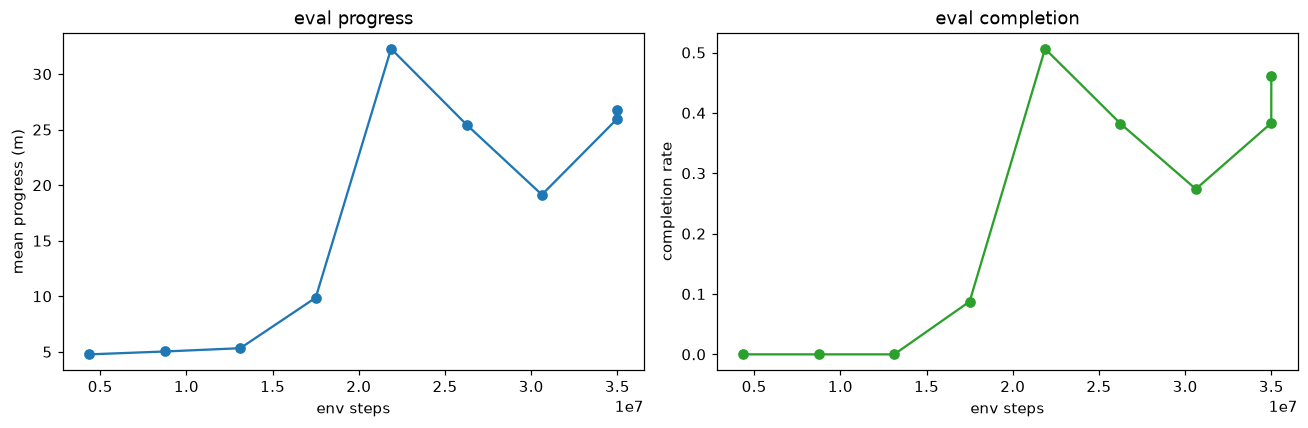

,mean_progress_m,completion_rate,offtrack_rate,mean_speed_mps,lap_time_s
Bowtie_track,41.816,0.785,0.456,1.687,9.448
New_York_Track,26.484,0.519,0.899,1.722,11.056
thunder_hill_open,32.727,0.278,0.917,2.056,17.854
arctic_open,23.998,0.081,0.994,2.155,17.218


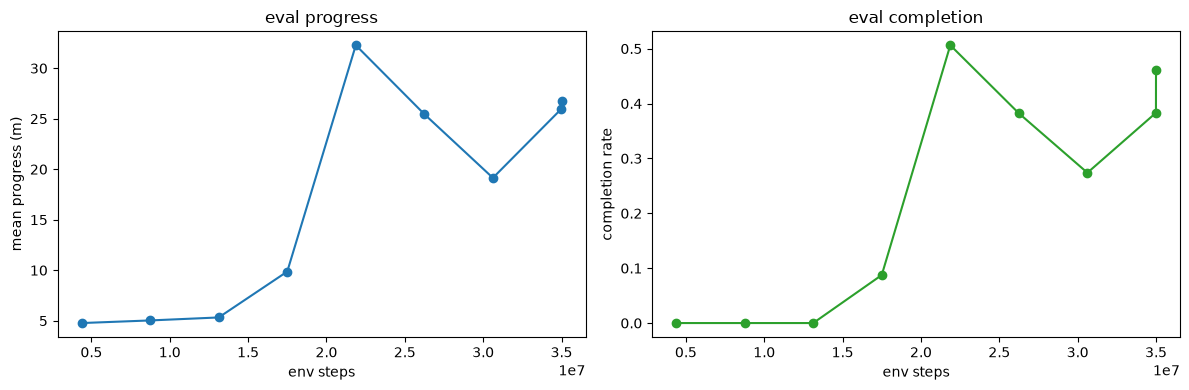

In [8]:
"""Learning curve + per-holdout-track completion."""

hist = pd.DataFrame(final["history"])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["frames"], hist["mean_progress_m"], marker="o")
ax[0].set(xlabel="env steps", ylabel="mean progress (m)", title="eval progress")
ax[1].plot(hist["frames"], hist["completion_rate"], marker="o", color="tab:green")
ax[1].set(xlabel="env steps", ylabel="completion rate", title="eval completion")
fig.tight_layout()
show_fig(fig)

display(pd.DataFrame(final["holdout"]).T[
    ["mean_progress_m", "completion_rate", "offtrack_rate",
     "mean_speed_mps", "lap_time_s"]].round(3))


Bowtie_track: 143 episodes, completion 51.7%, mean progress 28.5 m


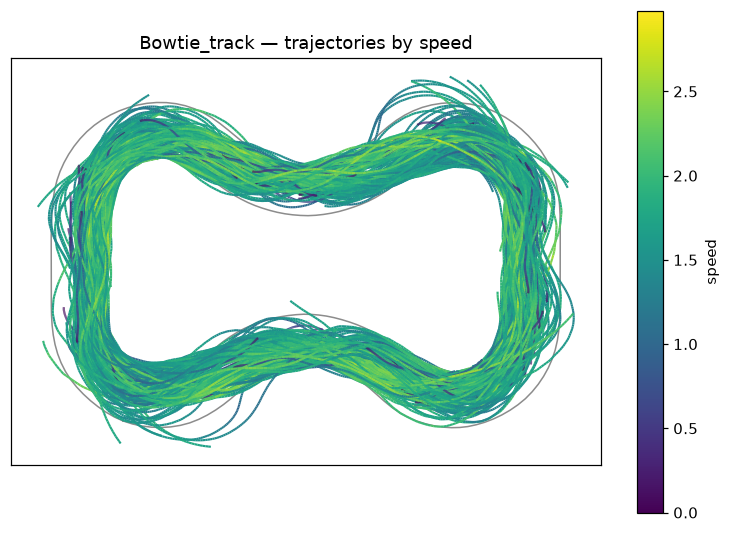

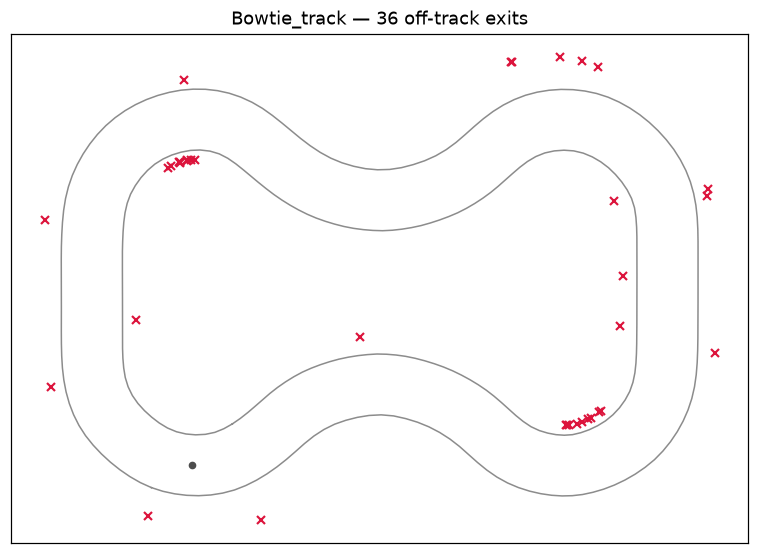

New_York_Track: 193 episodes, completion 42.5%, mean progress 22.2 m


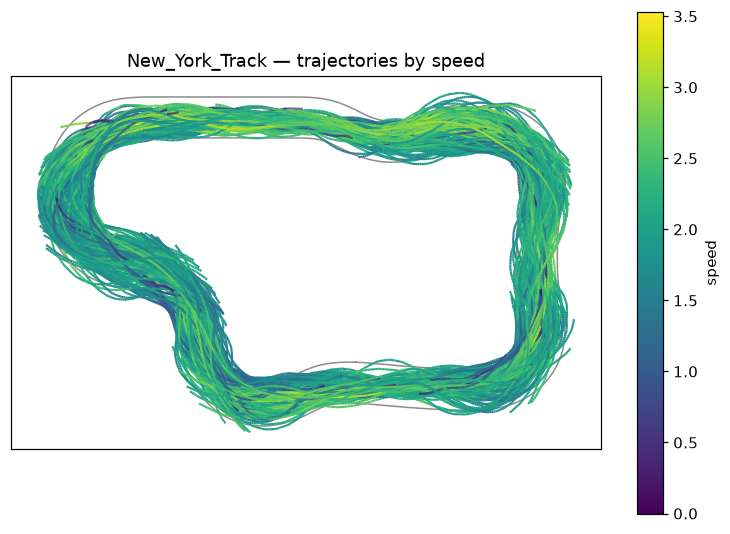

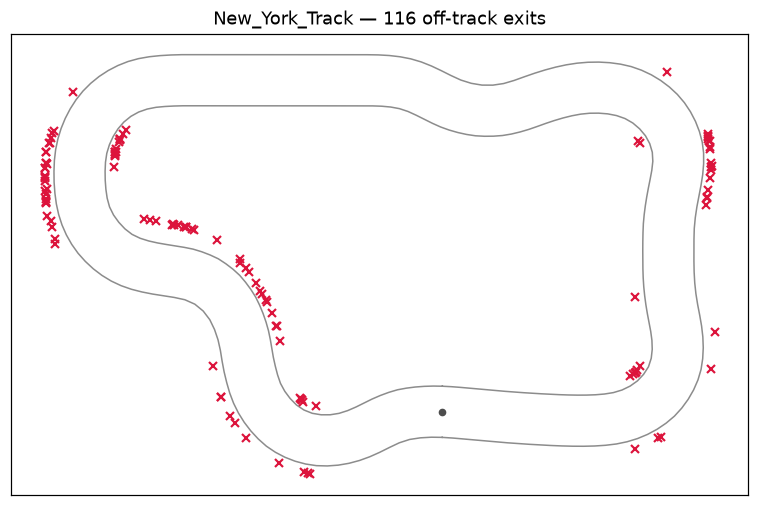

thunder_hill_open: 172 episodes, completion 23.3%, mean progress 28.0 m


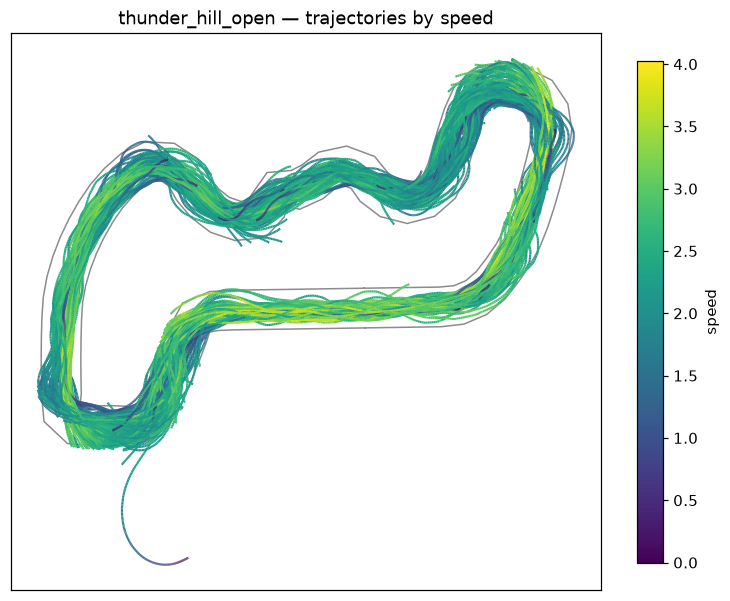

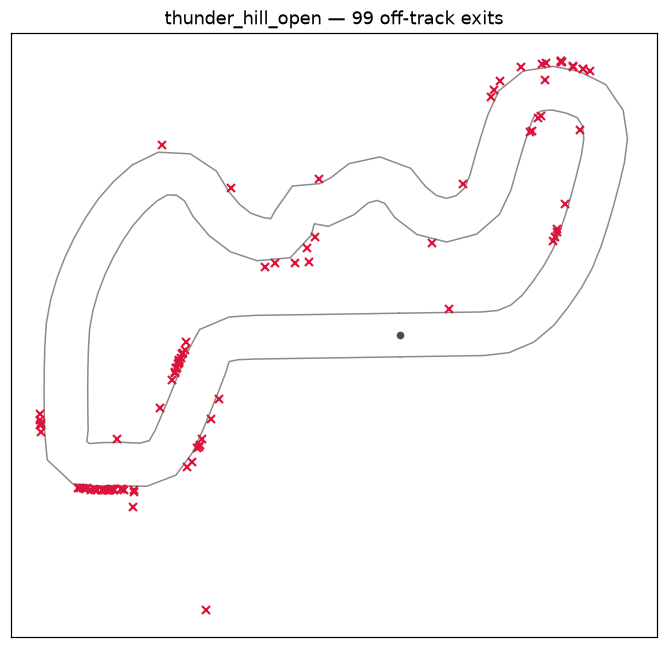

arctic_open: 237 episodes, completion 8.0%, mean progress 21.2 m


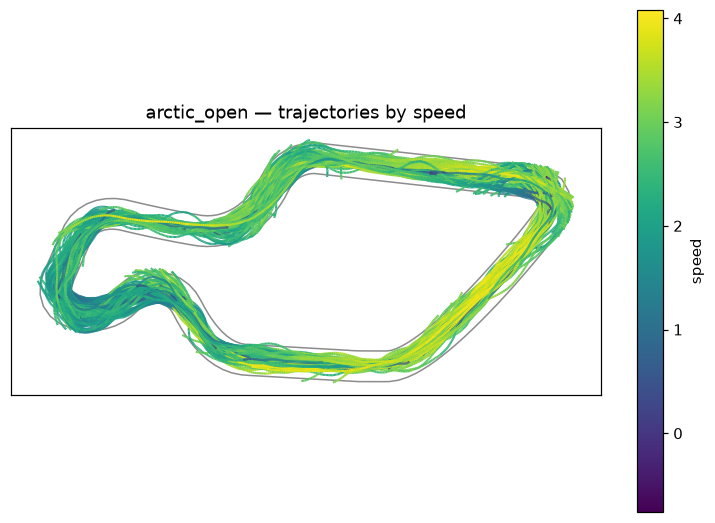

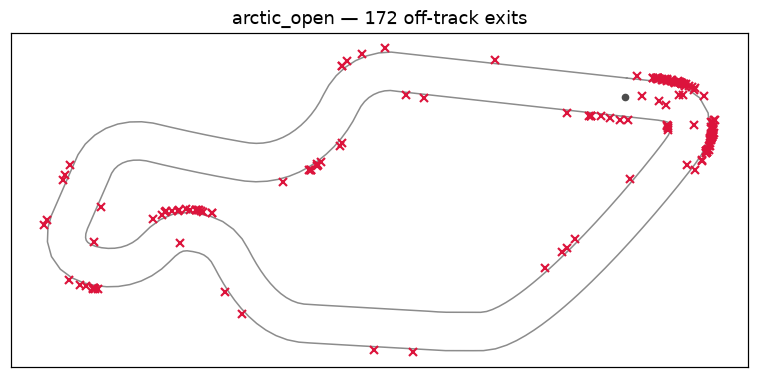

In [9]:
"""Trajectories and off-track exits on every never-seen circuit."""

import os

from deepracer_genesis.analysis.telemetry import episode_agg, load_telemetry
from deepracer_genesis.analysis.trackplots import (plot_offtrack_hotspots,
                                                   plot_trajectories)

for track in HOLDOUT_TRACKS:
    path = os.path.join(RUN_DIR, "telemetry", f"holdout_{track}.parquet")
    if not os.path.exists(path):
        print(f"{track}: no telemetry recorded")
        continue
    hdf = load_telemetry(path)
    agg = episode_agg(hdf)
    print(f"{track}: {len(agg)} episodes, "
          f"completion {agg['completed_lap'].mean():.1%}, "
          f"mean progress {agg['progress_total_m'].mean():.1f} m")
    show_fig(plot_trajectories(hdf, track, color_by="speed"))
    show_fig(plot_offtrack_hotspots(hdf, track))


In [10]:
"""Rollout video on the hardest holdout (cached like every other step)."""

vid = recorded("video")
if vid is None:
    import os

    from deepracer_genesis.experiment import rollout_video
    path = rollout_video(
        completion_spec(steps=FINAL_STEPS, eval_every=EVAL_EVERY,
                        variant=f"final_d{final.get('draw', 0)}",
                        **BEST_REWARD),
        ckpt=os.path.join(RUN_DIR, "model.pt"),
        track="thunder_hill_open", steps=400, num_envs=8)
    vid = record_result("video", {"video": path})
print(vid)


{'video': 'runs/best_camera_completion/best_camera_completion/final_d1-0-62fd8667fee0/videos/spectator_thunder_hill_open.mp4'}


In [11]:
"""The ONNX car bundle — the one step that cannot run in this process.

genesis and onnxruntime bundle clashing LLVM symbols, so the export runs
as a plain CLI call in a fresh process. It needs nothing from this
notebook: the run directory's ``eval_record.json`` + ``model.pt`` are
enough to rebuild and export the actor.
"""

import subprocess
import sys

subprocess.run([sys.executable, "-m", "deepracer_genesis.deploy.onnx",
                RUN_DIR, "--bundle-name", "best_camera_completion"], check=True)
print(f"car bundle: {RUN_DIR}/export/best_camera_completion.tar.gz")
print(f"total wall-clock: {elapsed_h():.2f} h")


<frozen runpy>:128: RuntimeWarning: 'deepracer_genesis.deploy.onnx' found in sys.modules after import of package 'deepracer_genesis.deploy', but prior to execution of 'deepracer_genesis.deploy.onnx'; this may result in unpredictable behaviour
<deepracer-genesis>/deepracer_genesis/experiment/spec.py:437: UserWarning: multi-track camera training uses Part O spatial tiling: all 7 track meshes load into every env (render + memory scale ~K); benchmark aggregate steps/sec before scaling the track count
  self._validate_obs_dr()


<deepracer-genesis>/deepracer_genesis/deploy/onnx.py:224: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


[export] WARNING: onnxruntime not installed — graph NOT verified against torch. Install the 'export' extra.
[export] policy.onnx + model_card.json + best_camera_completion.tar.gz -> runs/best_camera_completion/best_camera_completion/final_d1-0-75f935de3139/export  (onnxruntime missing: NOT verified)


car bundle: runs/best_camera_completion/best_camera_completion/final_d1-0-75f935de3139/export/best_camera_completion.tar.gz
total wall-clock: 0.00 h


## Notes

- **Bundle**: `<run_dir>/export/best_camera_completion.tar.gz` (opset-11
  ONNX + metadata) — same deployment path as rounds 1–2.
- **First post-fix round**: compare this round's holdout completion to
  round 2's (Bowtie 36.6% → 78.5%, New York 29.8% → 51.9%) for the
  sign-fix + reward-design gain.
- **Reproducibility**: seeded end to end; study resumes from
  `runs/best_camera_completion/study.db`; step records in
  `runs/best_camera_completion/logs/`; `REUSE = True` replays them.
